### BUSINESS QUESTION AND STORYTELLING

**Core question:**

- "What makes a red wine highly rated on Vivino?"

**Supporting questions:**

- "What drives price?"
- "Where do mismatches happen (expensive but low-rated)?"
- “Can we predict which red wines offer the best value for money?”
- “Which features most influence wine quality?”
- “Does price strongly correlate with rating?”
- “Are certain regions consistently higher value?”

### DATASETS

We use only Red.csv to keep the scope manageable and the business question clear. Varieties.csv is only a reference list of grape names and does not contain join keys or additional explanatory variables. Adding White, Rosé, and Sparkling would increase complexity without helping answer the core question: what drives higher ratings for red wines?

We created a derived variety_ml feature from wine name and region using rule-based text mapping to capture grape/style information not explicitly present in the original dataset.

In summary: We limited the project to Red.csv to keep the scope focused. We cleaned Year, transformed skewed numerical columns, reduced high-cardinality categorical features, and built a baseline model to predict highly rated wines. We also avoided leakage by not using any feature derived from the target.

**Recommended target**

Either:
- Classification: is_good = Rating >= 4.0
- Regression: predict Rating

**Baseline features**

- Country
- Region capped to top N
- Price → log_price
- NumberOfRatings → log_num_ratings
- Year cleaned
- optional engineered variety_ml if your team uses it

**Excluded from baseline**

- Name
- Winery
- any feature derived from Rating if Rating is the target

### NOTE: in Bea's notebook, I renamed the fallback categories to better reflect their meaning:

- **Rare Varieties** → real but rare varieties of grapes; too rare to keep as its own class. Examples: Tannat, Mourvèdre, Gamay, Aglianico. For ML, keeping dozens of tiny categories hurts performance. So we grouped them.

- **Unspecified Red** → wines labeled as red without grape info; the producer made intentionally vague labels. Examples: “Rouge 2016”, “Rosso Toscana”, “Red Wine”, “Toscana 2015”

- **Unknown Variety** → no identifiable information; no grape and no region compounded with useless keywords. Examples: “Grande Cuvée”, “Tradition”, “Selection”, “G 2015”.

This makes the feature clearer and more interpretable.

We did that by engineering a structured variety feature from **unstructured text** using normalization, regex matching, and region-based inference, then optimized it for ML by reducing category sparsity.

In [71]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")

BASE_PATH = "../data/raw/"

red_full = pd.read_csv(BASE_PATH + "red_ml_final.csv")
red_model = pd.read_csv(BASE_PATH + "red_ml_model_input.csv")

wine_red = "#8C1B1B"

In [72]:
print(red_full.shape)
print(red_model.shape)

(8666, 12)
(8666, 5)


In [73]:
print(red_full.head())
print(red_model.head())

                                 name  country     region  \
0                        Pomerol 2011   France    Pomerol   
1                          Lirac 2017   France      Lirac   
2  Erta e China Rosso di Toscana 2015    Italy    Toscana   
3                      Bardolino 2019    Italy  Bardolino   
4      Ried Scheibner Pinot Noir 2016  Austria  Carnuntum   

                  winery  rating  numberofratings  price  year  \
0  Château La Providence     4.2              100  95.00  2011   
1     Château Mont-Redon     4.3              100  15.50  2017   
2             Renzo Masi     3.9              100   7.45  2015   
3             Cavalchina     3.5              100   8.72  2019   
4            Markowitsch     3.9              100  29.15  2016   

                           name_clean region_clean         variety  \
0                        pomerol 2011      pomerol  Bordeaux Blend   
1                          lirac 2017        lirac     Rhone Blend   
2  erta e china rosso di t

In [74]:
print(red_full.columns.tolist())
print(red_model.columns.tolist())

['name', 'country', 'region', 'winery', 'rating', 'numberofratings', 'price', 'year', 'name_clean', 'region_clean', 'variety', 'variety_ml']
['country', 'region', 'price', 'rating', 'variety_ml']


In [75]:
print(red_model["variety_ml"].value_counts())

variety_ml
Unknown Variety       1390
Bordeaux Blend        1216
Rare Varieties         889
Tempranillo            841
Unspecified Red        732
Pinot Noir             479
Cabernet Sauvignon     478
Sangiovese             447
Rhône Blend            304
Nebbiolo               271
Merlot                 259
Corvina                240
Shiraz                 219
Syrah                  206
Malbec                 178
Primitivo              129
Barbera                127
Montepulciano          113
Grenache                75
Blend                   73
Name: count, dtype: int64


In [76]:
# Adding value score for storytelling in Tableau
red_full["value_score"] = red_full["rating"] / red_full["price"]

In [77]:
# red_full.to_csv("../data/raw/red_ml_final_valuescore.csv", index=False)

In [78]:
red_full.groupby("country").filter(lambda x: len(x) > 20)

,name,country,region,winery,rating,numberofratings,price,year,name_clean,region_clean,variety,variety_ml,value_score
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011,pomerol 2011,pomerol,Bordeaux Blend,Bordeaux Blend,0.044211
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017,lirac 2017,lirac,Rhone Blend,Rhône Blend,0.277419
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015,erta e china rosso di toscana 2015,toscana,Generic Red,Unspecified Red,0.523490
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019,bardolino 2019,bardolino,Corvina,Corvina,0.401376
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016,ried scheibner pinot noir 2016,carnuntum,Pinot Noir,Pinot Noir,0.133791
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8661,6th Sense Syrah 2016,United States,Lodi,Michael David Winery,3.8,994,16.47,2016,6th sense syrah 2016,lodi,Syrah,Syrah,0.230723
8662,Botrosecco Maremma Toscana 2016,Italy,Maremma Toscana,Le Mortelle,4.0,995,20.09,2016,botrosecco maremma toscana 2016,maremma toscana,Generic Red,Unspecified Red,0.199104
8663,Haut-Médoc 2010,France,Haut-Médoc,Château Cambon La Pelouse,3.7,996,23.95,2010,haut medoc 2010,haut medoc,Bordeaux Blend,Bordeaux Blend,0.154489
8664,Shiraz 2019,Australia,South Eastern Australia,Yellow Tail,3.5,998,6.21,2019,shiraz 2019,south eastern australia,Shiraz,Shiraz,0.563607


### 1. Feature importance (most important slide)

**What actually drives high ratings?**

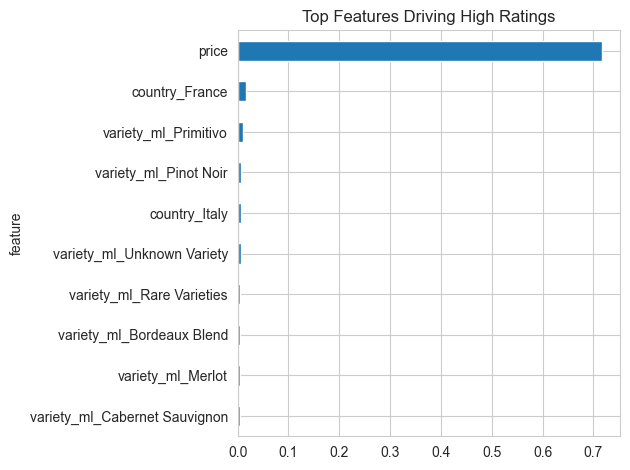

In [79]:
# prepare training data from red_model
X = pd.get_dummies(red_model.drop(columns=["rating"]), drop_first=True)
y = red_model["rating"]

# train model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X, y)

feature_importance = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.title("Top Features Driving High Ratings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

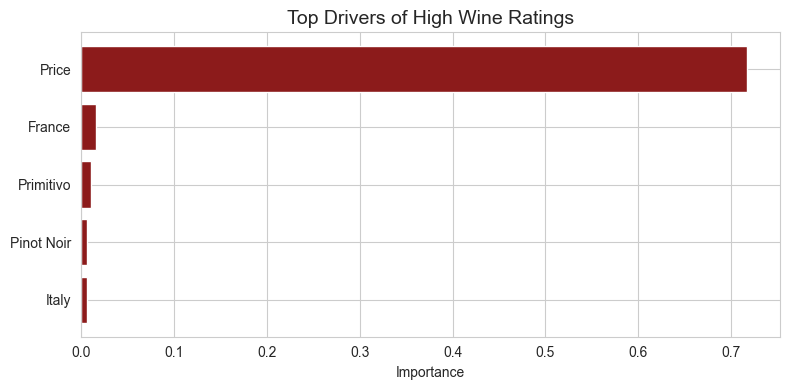

In [80]:
# Focus on top 5 for storytelling, cleaner visualization

def clean_feature_name(name):
    name = name.replace("variety_ml_", "")
    name = name.replace("country_", "")
    name = name.replace("_", " ")
    return name.title()

importance_df["feature_clean"] = importance_df["feature"].apply(clean_feature_name)
importance_df = importance_df.head(5)

plt.figure(figsize=(8,4))
plt.barh(importance_df["feature_clean"], importance_df["importance"], color="#8C1B1B")

plt.title("Top Drivers of High Wine Ratings", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 2. Price vs Rating (intuition check)

**Is high price a strong predictor of higher ratings?**

No.

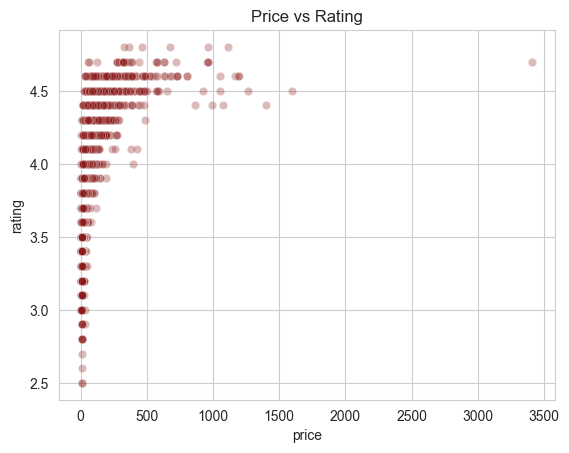

In [81]:
sns.scatterplot(data=red_full, x="price", y="rating", color=wine_red, alpha=0.3)
plt.title("Price vs Rating")
plt.show()

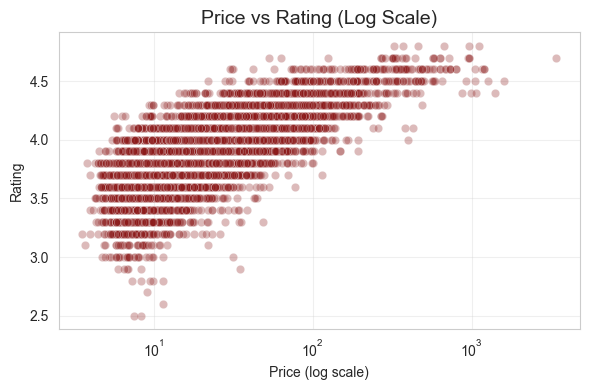

In [82]:
# Clearer visualization with log scale for price
plt.figure(figsize=(6,4))

sns.scatterplot(data=red_full, x="price", y="rating", color=wine_red, alpha=0.3)

plt.xscale("log")   # KEY FIX

plt.title("Price vs Rating (Log Scale)", fontsize=14)
plt.xlabel("Price (log scale)")
plt.ylabel("Rating")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

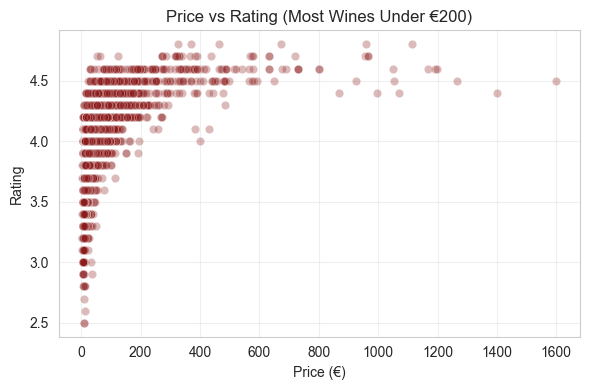

In [83]:
df_filtered = red_full[red_full["price"] < 2000]

plt.figure(figsize=(6,4))
sns.scatterplot(data=df_filtered, x="price", y="rating", color=wine_red,alpha=0.3)

plt.title("Price vs Rating (Most Wines Under €200)")
plt.xlabel("Price (€)")
plt.ylabel("Rating")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Best value countries

**Which countries give you the best rating relative to how much you pay?**

This chart shows which countries offer the best value, meaning higher ratings relative to price. A higher score means you’re getting more quality per euro spent.

Interestingly, some less traditional wine-producing countries rank highly, suggesting that good value can be found outside premium regions. However, this may be influenced by smaller sample sizes, so we filtered countries with very few wines to make the comparison more reliable.

In [84]:
red_full["value_score"] = red_full["rating"] / red_full["price"]

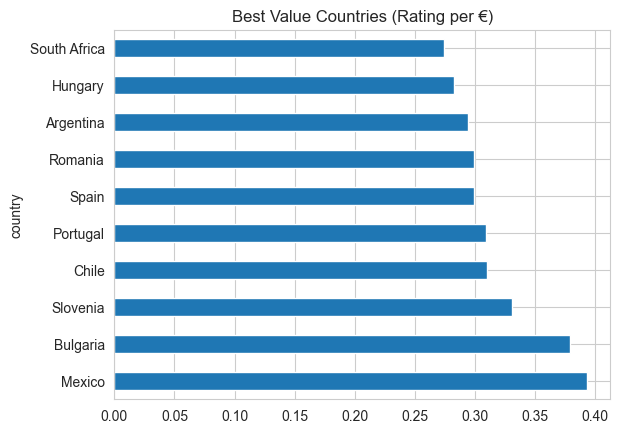

In [85]:
red_full["value_score"] = red_full["rating"] / red_full["price"]

value_by_country = (
    red_full.groupby("country")["value_score"]
    .mean()
    .sort_values(ascending=False)
)

value_by_country.head(10).plot(kind="barh")
plt.title("Best Value Countries (Rating per €)")
plt.show()

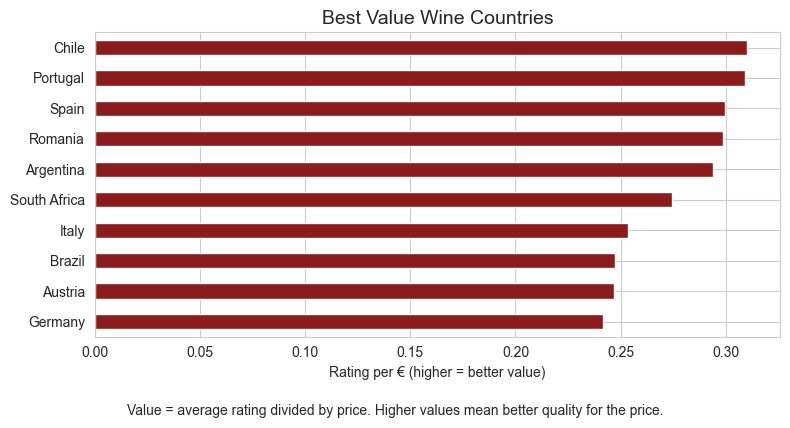

In [86]:
# Filtered chart with only countries having >20 wines, clearer visualization

value_by_country = (
    red_full.groupby("country")
    .filter(lambda x: len(x) > 20)
    .groupby("country")["value_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
value_by_country.plot(kind="barh", color="#8C1B1B")

plt.title("Best Value Wine Countries", fontsize=14)
plt.xlabel("Rating per € (higher = better value)")
plt.ylabel("")

plt.gca().invert_yaxis()

# Add explanation under chart
plt.figtext(
    0.5, -0.05,
    "Value = average rating divided by price. Higher values mean better quality for the price.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [87]:
old_value_by_country = (
    red_full.groupby("country")["value_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(old_value_by_country)

country
Mexico          0.393064
Bulgaria        0.379172
Slovenia        0.331120
Chile           0.310280
Portugal        0.309268
Spain           0.299621
Romania         0.298875
Argentina       0.294070
Hungary         0.282961
South Africa    0.274322
Name: value_score, dtype: float64


In [88]:
new_value_by_country = (
    red_full.groupby("country")
    .filter(lambda x: len(x) > 20)
    .groupby("country")["value_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(new_value_by_country)

country
Chile           0.310280
Portugal        0.309268
Spain           0.299621
Romania         0.298875
Argentina       0.294070
South Africa    0.274322
Italy           0.253526
Brazil          0.247174
Austria         0.246768
Germany         0.241812
Name: value_score, dtype: float64


### NOTE: the last visualization removed countries with too few wines.

So before, countries like:
- Mexico
- Bulgaria
- Slovenia
- Hungary

may have ranked highly because they had very few wines with good value scores.

Now those small-sample countries are **excluded**, so the chart is more stable and more trustworthy.

### KEY INSIGHTS:

- Insight 1: Price is everything! The model shows that price is by far the strongest predictor of high ratings. However, this likely reflects underlying factors such as brand, region, and reputation rather than price itself.

- Insight 2: Origin matters (certain countries consistently produce higher-rated wines).

- Insight 3: Value exists outside premium regions (some countries offer significantly better value, meaning higher ratings per euro).

We found that price is the strongest predictor of high ratings in our model, likely acting as a proxy for factors like brand and reputation. However, exploratory analysis shows that price alone does not guarantee higher quality, as ratings remain tightly clustered across all price levels. Additionally, our value analysis highlights that some less traditional wine-producing countries offer strong quality at lower prices, suggesting that consumers can find excellent wines beyond premium regions.

Higher prices do NOT strongly increase ratings.